# Introduction
This jupyter notebook describes the building process for a neural network from scratch (with numpy as help) to recognize handwritten digits using the MNIST dataset.


# Prerequisites
Libraries like NumPy and Matplotlib are needed to run this cause they implement and make the math easier to work with while also giving access to make Diagrams for explanation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct
import os
import urllib.request
import gzip
import re
from PIL import Image, ImageDraw, ImageFilter
from sympy.printing.pretty.pretty_symbology import line_width

Another thing we need would be training data and for that we can use the MNIST dataset which contains ~70000 images of handwritten digits to train on.
For this we need to download the dataset and prepare it for use.

In [2]:
MNIST_URLS = {
    "train_images": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
    "train_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
    "test_images":  "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz",
    "test_labels":  "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz",
}

# Directories for data storage
DATA_DIR = "../data_raw"
MODELS_DIR = "../models"

# To make the training reproducible
np.random.seed(3227)

def download_mnist() -> None:
    """
    Download the MNIST dataset and save it to the DATA_DIR directory.
    Skips files that already exist.
    """
    os.makedirs(DATA_DIR, exist_ok=True)
    
    for name, url in MNIST_URLS.items():
        filepath = os.path.join(DATA_DIR, f"{name}.gz")
        
        if not os.path.exists(filepath):
            print(f"Downloading {name}...")
            urllib.request.urlretrieve(url, filepath)
            print(f" Saved to {filepath}.")
        else:
            print(f"Already have {name}")
            
    
def load_images(filename: str) -> np.ndarray:
    """
    Load image data from a compressed MNIST file.

    Args:
        filename (str): Name of the file (without .gz) in DATA_DIR.

    Returns:
        np.ndarray: Array of images, normalized to values between 0 and 1.
    """
    filepath = os.path.join(DATA_DIR, f"{filename}.gz")
    
    with gzip.open(filepath, "rb") as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        raw_data = np.frombuffer(f.read(), dtype=np.uint8)
    
    images = raw_data.reshape(num_images, rows * cols).astype(np.float32) / 255.0
    return images


def load_labels(filename: str) -> np.ndarray:
    """
    Load label data from a compressed MNIST file.

    Args:
        filename (str): Name of the file (without .gz) in DATA_DIR.

    Returns:
        np.ndarray: Array of labels.
    """
    filepath = os.path.join(DATA_DIR, f"{filename}.gz")
    
    with gzip.open(filepath, "rb") as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        
    return labels


# Download the dataset and load it into variables
download_mnist()

train_images = load_images("train_images")
train_labels = load_labels("train_labels")
test_images = load_images("test_images")
test_labels = load_labels("test_labels")

print(f"\nTraining: {train_images.shape[0]} images, each {train_images.shape[1]} pixels")
print(f"Testing:  {test_images.shape[0]} images")
print(f"Pixel value range: [{train_images.min():.1f}, {train_images.max():.1f}]")
print(f"Label range: [{train_labels.min()}, {train_labels.max()}]")

Already have train_images
Already have train_labels
Already have test_images
Already have test_labels

Training: 60000 images, each 784 pixels
Testing:  10000 images
Pixel value range: [0.0, 1.0]
Label range: [0, 9]


Now that we have the dataset we can work with it to build the NN (Neural Network) that can identify them.
But before that we still need to augment the images to make the model more stable in realworld tests and works better with german numbers.
Here is also a visualization of the raw MNIST dataset.

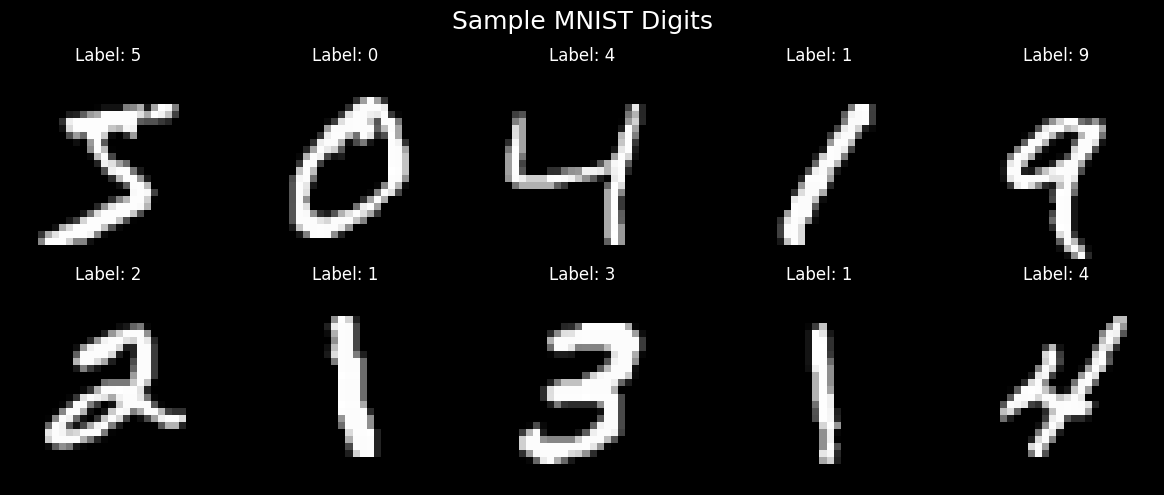

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    image = train_images[i].reshape(28, 28)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {train_labels[i]}")
    ax.axis("off")

plt.suptitle("Sample MNIST Digits", fontsize=18)
plt.tight_layout()
plt.show()

# Augmentation
In this step we will transform the images to new ones with different strategies for different use cases. We then give this information with the normal MNIST dataset to the model to make it smarter especially in realworld applications.

In [4]:
def augment_rotate(image: np.ndarray, max_angle: int = 15) -> np.ndarray:
    """
    
    Args:
        image: 
        max_angle: 

    Returns:

    """
    img = Image.fromarray((image.reshape(28, 28) * 255).astype(np.uint8), mode="L")
    angle = np.random.uniform(-max_angle, max_angle)
    img = img.rotate(angle, fillcolor=0)
    return np.array(img).astype(np.float32).flatten() / 255.0


def augment_shift(image: np.ndarray, max_shift: int = 3) -> np.ndarray:
    """
    
    Args:
        image: 
        max_shift: 

    Returns:

    """
    img = image.reshape(28, 28)
    dx = np.random.randint(-max_shift, max_shift + 1)
    dy = np.random.randint(-max_shift, max_shift + 1)
    result = np.zeros_like(img)
    
    src_y = slice(max(0, -dy), min(28, 28 - dy))
    src_x = slice(max(0, -dx), min(28, 28 - dx))
    dst_y = slice(max(0, dy), min(28, 28 + dy))
    dst_x = slice(max(0, dx), min(28, 28 + dx))
    
    result[dst_y, dst_x] = img[src_y, src_x]
    return result.flatten()


def augment_scale(image: np.ndarray, scale_range: tuple[float] = (0.8, 1.2)) -> np.ndarray:
    """
    
    Args:
        image: 
        scale_range: 

    Returns:

    """
    img = Image.fromarray((image.reshape(28, 28) * 255).astype(np.uint8), mode="L")
    scale = np.random.uniform(*scale_range)
    new_size = max(1, int(28 * scale))
    
    img = img.resize((new_size, new_size), Image.LANCZOS)
    result = np.zeros((28, 28), dtype=np.uint8)
    
    offset_y = (28 - new_size) // 2
    offset_x = (28 - new_size) // 2
    
    src_y_start = max(0, -offset_y)
    src_x_start = max(0, -offset_x)
    dst_y_start = max(0, offset_y)
    dst_x_start = max(0, offset_x)
    h = min(new_size - src_y_start, 28 - dst_y_start)
    w = min(new_size - src_x_start, 28 - dst_x_start)
    
    scaled_arr = np.array(img)
    result[dst_y_start:dst_y_start + h, dst_x_start:dst_x_start + w] = scaled_arr[src_y_start:src_y_start + h, src_x_start:src_x_start + w]
    
    return result.astype(np.float32).flatten() / 255.0


def augment_noise(image: np.ndarray, noise_std: float = 0.1) -> np.ndarray:
    """
    
    Args:
        image: 
        noise_std: 

    Returns:

    """
    noise = np.random.normal(0, noise_std, size=image.shape).astype(np.float32)
    noisy = image + noise
    return np.clip(noisy, 0.0, 1.0)


def augment_thickness(image: np.ndarray) -> np.ndarray:
    """
    
    Args:
        image: 

    Returns:

    """
    img = Image.fromarray((image.reshape(28, 28) * 255).astype(np.uint8), mode="L")
    
    if np.random.random() < 0.5:
        img = img.filter(ImageFilter.MaxFilter(3))
    else:
        img = img.filter(ImageFilter.MinFilter(3))
    
    return np.array(img).astype(np.float32).flatten() / 255.0


def augment_german_one(image: np.ndarray) -> np.ndarray:
    """
    
    Args:
        image: 

    Returns:

    """
    img_arr = (image.reshape(28, 28) * 255).astype(np.uint8)
    
    rows_with_ink = np.where(img_arr.max(axis=1) > 30)[0]
    cols_with_ink = np.where(img_arr.max(axis=0) > 30)[0]
    
    if len(rows_with_ink) == 0 or len(cols_with_ink) == 0:
        return image
    
    top_row = rows_with_ink[0]
    top_col = int(np.mean(np.where(img_arr[top_row] > 30)[0]))
    
    pil_img = Image.fromarray(img_arr, mode="L")
    draw = ImageDraw.Draw(pil_img)
    
    serif_len = np.random.randint(4, 8)
    line_width = np.random.randint(1, 3)
    end_row = top_row + serif_len
    end_col = top_col - serif_len
    ink_value = max(100, min(255, np.random.randint(170, 240)))
    
    draw.line([(top_col, top_row), (end_col, end_row)], fill=ink_value, width=line_width)
    
    return np.array(pil_img).astype(np.float32).flatten() / 255.0


def augment_random(image: np.ndarray, label=None) -> np.ndarray:
    general_augmentations = [
        augment_rotate,
        augment_shift,
        augment_scale,
        augment_noise,
        augment_thickness,
    ]
    
    num_augments = np.random.randint(1, 4)
    chosen = np.random.choice(len(general_augmentations), size=num_augments, replace=False)
    
    result = image.copy()
    for idx in chosen:
        result = general_augmentations[idx](result)
        
    return result

Augmenting training data...
Adding 5000 German '1' variants...
Training set: 185000 images (125000 augmented)


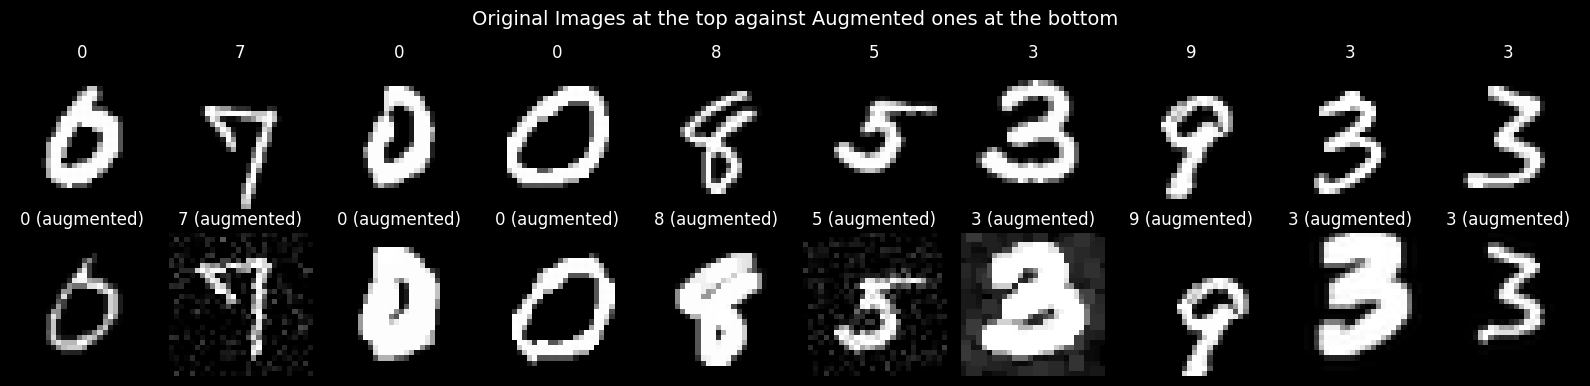

In [5]:
print("Augmenting training data...")
aug_images = []
aug_labels = []

for i in range(len(train_images)):
    for _ in range(2):
        aug_img = augment_random(train_images[i], train_labels[i])
        aug_images.append(aug_img)
        aug_labels.append(train_labels[i])
        
one_indices = np.where(train_labels == 1)[0]
num_german_ones = 5000

print(f"Adding {num_german_ones} German '1' variants...")
for _ in range(num_german_ones):
    idx = np.random.choice(one_indices)
    german_one = augment_german_one(train_images[idx])
    german_one = augment_random(german_one, label=1)
    aug_images.append(german_one)
    aug_labels.append(1)
    

train_images = np.concatenate([train_images, np.array(aug_images)], axis=0)
train_labels = np.concatenate([train_labels, np.array(aug_labels, dtype=np.uint8)], axis=0)

print(f"Training set: {len(train_images)} images ({len(train_images) - 60000} augmented)")

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle("Original Images at the top against Augmented ones at the bottom", fontsize=14)

for i in range(10):
    idx = np.random.randint(0, 60000)
    axes[0, i].imshow(train_images[idx].reshape(28, 28), cmap="gray")
    axes[0, i].set_title(f"{train_labels[idx]}")
    axes[0, i].axis('off')
    
    aug = augment_random(train_images[idx])
    axes[1, i].imshow(aug.reshape(28, 28), cmap="gray")
    axes[1, i].set_title(f"{train_labels[idx]} (augmented)")
    axes[1, i].axis('off')
    
plt.tight_layout()
plt.show()

# Neural Network
For the Start we need some basic functions to work with the array in the NN. The first is called ReLU and stands for Rectified Linear Unit.
It basically takes all negative values and makes them zero but leaves the positive ones untouched.
This helps by adding nonlinearity which results in the model being able to learn more complex patterns.
Then we also need the derivative function of ReLU to get the slope of the function (0 for neg numbers and 1 for pos numbers) later needed for the backpropagation.
Lastly we need softmax to convert our outputs into a spectrum of numbers from 0 to 1 and summing to exactly one so we know the likelihood of a certain number.

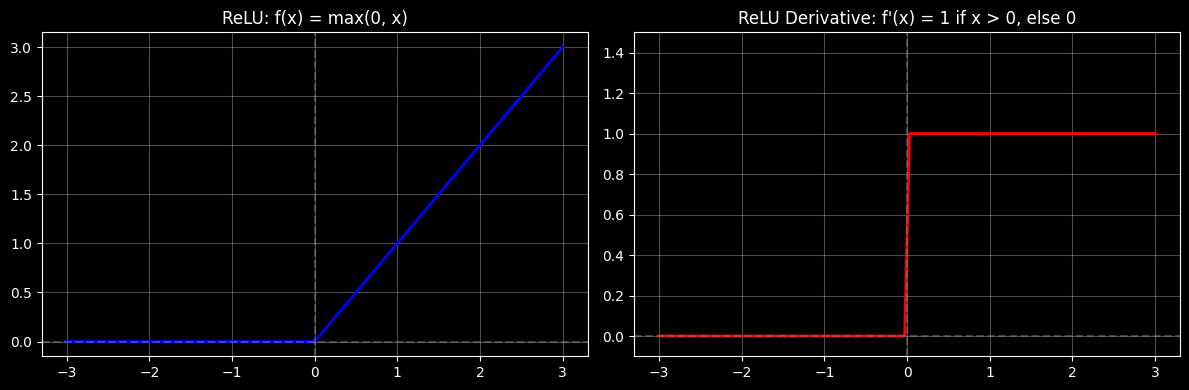

In [6]:
def relu(z: np.ndarray) -> np.ndarray:
    """
    Apply the ReLU activation function to the input array.

    Args:
        z (np.ndarray): Input values.

    Returns:
        np.ndarray: Output values after ReLU.
    """
    return np.maximum(0, z)


def relu_derivative(z: np.ndarray) -> np.ndarray:
    """
    Compute the derivative of the ReLU function.

    Args:
        z (np.ndarray): Input values.

    Returns:
        np.ndarray: Derivative values (0 or 1).
    """
    return (z > 0).astype(np.float32)


def softmax(z: np.ndarray) -> np.ndarray:
    """
    Apply the softmax function to the input array.

    Args:
        z (np.ndarray): Input values (2D array).

    Returns:
        np.ndarray: Probability distribution for each row.
    """
    shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# Visualisation of ReLU and ReLU Derivative
x = np.linspace(-3, 3, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, relu(x), linewidth=2, color="blue")
axes[0].set_title("ReLU: f(x) = max(0, x)")
axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[0].axvline(x=0, color="gray", linestyle="--", alpha=0.5)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, relu_derivative(x), linewidth=2, color="red")
axes[1].set_title("ReLU Derivative: f'(x) = 1 if x > 0, else 0")
axes[1].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[1].axvline(x=0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_ylim(-0.1, 1.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Now that we have the basic function we can start building the NN.

In [7]:
class NeuralNetwork:
    """
    A simple multi-layer neural network for classifying handwritten digits.
    Supports arbitrary number and size of hidden layers.
    """

    def __init__(self, input_size: int = 784, hidden_layers: list = None, output_size: int = 10):
        """
        Initialize the network with random weights and biases.

        Args:
            input_size (int): Size of the input layer.
            hidden_layers (list): List of hidden layer sizes.
            output_size (int): Size of the output layer.
        """
        if hidden_layers is None:
            hidden_layers = [256, 128]
            
        layers = [input_size] + hidden_layers + [output_size]
        
        self.weights = []
        self.biases = []
        
        for layerIdx in range(len(layers) - 1):
            W = np.random.randn(layers[layerIdx], layers[layerIdx+1]).astype(np.float32) * np.sqrt(2.0 / layers[layerIdx])
            b = np.zeros(layers[layerIdx+1]).astype(np.float32)
            
            self.weights.append(W)
            self.biases.append(b)
            
        self._cache = {}
        
    
    def forward_pass(self, forward_x: np.ndarray) -> np.ndarray:
        """
        Perform a forward pass through the network.

        Args:
            forward_x (np.ndarray): Input data (batch).

        Returns:
            np.ndarray: Network outputs (probabilities).
        """
        a = forward_x
        activations = [forward_x]
        pre_activations = []
        
        for forwardIdx in range(len(self.weights)):
            W = self.weights[forwardIdx]
            b = self.biases[forwardIdx]
            
            z = np.dot(a, W) + b
            pre_activations.append(z)
            
            if forwardIdx == len(self.weights) - 1:
                a = softmax(z)
            else:
                a = relu(z)
                
            activations.append(a)
        
        self._cache = {
            "activations": activations,
            "pre_activations": pre_activations,
        }
        
        return a
            
        
    def backpropagation(self, y_true: np.ndarray) -> dict:
        """
        Perform backpropagation and compute gradients for weights and biases.

        Args:
            y_true (np.ndarray): True labels (one-hot).

        Returns:
            dict: Gradients for weights ('dW') and biases ('db').
        """
        activations = self._cache["activations"]
        pre_activations = self._cache["pre_activations"]
        batch_size = activations[0].shape[0]
        L = len(self.weights)
        
        dW = [None] * L
        db = [None] * L
        
        aL = activations[-1]
        dz = aL - y_true
        
        a_prev = activations[-2]
        dW[L - 1] = np.dot(a_prev.T, dz) / batch_size
        db[L - 1] = np.mean(dz, axis=0)
        
        for layer_idx in range(L - 2, -1, -1):
            W_next = self.weights[layer_idx + 1]
            
            da = np.dot(dz, W_next.T)
            
            z_current = pre_activations[layer_idx]
            relu_prime = relu_derivative(z_current) 
            
            dz = da * relu_prime
            
            a_prev = activations[layer_idx]
            dW[layer_idx] = np.dot(a_prev.T, dz) / batch_size
            db[layer_idx] = np.mean(dz, axis=0)
        
        return {"dW": dW, "db": db}
    
    
    def update_weights(self, gradients: dict, learning_rate: float) -> None:
        """
        Update the network weights and biases with the computed gradients.

        Args:
            gradients (dict): Contains 'dW' and 'db'.
            learning_rate (float): Learning rate.
            
        Raises:
            ValueError: If gradient lists do not match the number of weight/bias arrays.
        """
        dW_list = gradients["dW"]
        db_list = gradients["db"]

        if len(dW_list) != len(self.weights) or len(db_list) != len(self.biases):
            raise ValueError("Gradient lists must match the number of weight/bias arrays")
        
        for updateIdx in range(len(self.weights)):
            self.weights[updateIdx] -= learning_rate * dW_list[updateIdx]
            self.biases[updateIdx] -= learning_rate * db_list[updateIdx]
            
    
    def predict(self, x_predict: np.ndarray) -> np.ndarray:
        """
        Return the predicted classes for the input data.

        Args:
            x_predict (np.ndarray): Input data.

        Returns:
            np.ndarray: Predicted class labels.
        """
        probs = self.forward_pass(x_predict)
        return np.argmax(probs, axis=1)
    
    
    def save_legacy(self, filepath: str, directory: str = MODELS_DIR) -> None:
        """
        Save the network weights and biases to a .npz file.

        Args:
            filepath (str): Filename.
            directory (str): Target directory.
        """
        os.makedirs(directory, exist_ok=True)
        filepath = os.path.join(directory, filepath)
        
        if filepath.endswith(".npz"):
            filepath = filepath[:-4]
        
        save_dict = {}
        
        layer_dims = [self.weights[0].shape[0]] + [w.shape[1] for w in self.weights]
        save_dict["dimensions"] = np.array(layer_dims)
        
        for saveIdx, (W, b) in enumerate(zip(self.weights, self.biases)):
            save_dict[f"W{saveIdx}"] = W
            save_dict[f"b{saveIdx}"] = b
    
        np.savez_compressed(filepath, **save_dict)
        print(f"Model saved to {filepath}")


    def save_with_metadata(self, filepath: str, epochs: int, learning_rate: float, batch_size: int, train_acc: float, test_acc: float, directory: str = MODELS_DIR) -> None:
        """
        Save the network weights and biases with additional metadata to an .npz file.
        
        Args:
            filepath: Name of the model file.
            epochs: Number of epochs the model was trained on.
            learning_rate: Learning rate used to train the model.
            batch_size: Size of the batches of images.
            train_acc: Final accuracy of the training set.
            test_acc: Final accuracy of the test set.
            directory: Path to the directory where the model will be saved.
        """
        os.makedirs(directory, exist_ok=True)
        filepath = os.path.join(directory, filepath)
        if filepath.endswith(".npz"):
           filepath = filepath[:-4]
        save_dict = {}
        layer_dims = [self.weights[0].shape[0]] + [w.shape[1] for w in self.weights]
        save_dict["dimensions"] = np.array(layer_dims)
        for saveIdx, (W, b) in enumerate(zip(self.weights, self.biases)):
            save_dict[f"W{saveIdx}"] = W
            save_dict[f"b{saveIdx}"] = b
        save_dict["epochs"] = np.array([epochs])
        save_dict["learning_rate"] = np.array([learning_rate])
        save_dict["batch_size"] = np.array([batch_size])
        save_dict["train_acc"] = np.array([train_acc])
        save_dict["test_acc"] = np.array([test_acc])
        np.savez_compressed(filepath, **save_dict)
        print(f"Model saved to {filepath}") 
        
        
    def load(self, filepath: str, directory: str = MODELS_DIR) -> None:
        """
        Load network weights and biases from a .npz file.

        Args:
            filepath (str): Filename.
            directory (str): Source directory.
            
        Raises:
            ValueError: If the file contains an error (malformed).
        """
        os.makedirs(directory, exist_ok=True)
        
        if not filepath.endswith(".npz"):
            filepath += ".npz"
        
        filepath = os.path.join(directory, filepath)
        with np.load(filepath) as data:
            if "dimensions" not in data:
                raise ValueError(f"File {filepath} is missing 'dimensions' metadata")
            
            W_keys = sorted([k for k in data.files if re.fullmatch(r"W\d+", k)], key=lambda x: int(x[1:]))
            b_keys = sorted([k for k in data.files if re.fullmatch(r"b\d+", k)], key=lambda x: int(x[1:]))

            if len(W_keys) != len(b_keys):
                raise ValueError("Saved file is malformed: unequal number of W and b arrays")

            weights = []
            biases = []
            for wk, bk in zip(W_keys, b_keys):
                weights.append(data[wk])
                biases.append(data[bk])
            
        self.weights = weights
        self.biases = biases
        print(f"Model loaded from {filepath}")
        
        
    def count_parameters(self) -> int:
        """
        Count the total number of trainable parameters in the network.

        Returns:
            int: Number of parameters.
        """
        total = 0
        for W, b in zip(self.weights, self.biases):
            total += W.size + b.size
            
        return total
    


In [8]:
net = NeuralNetwork()
total_params = net.count_parameters()

print(f"Network Created with {total_params} parameters")
for i, (W, b) in enumerate(zip(net.weights, net.biases), start=1):
    print(f" Layer {i}: W{i}{W.shape}, b{i}{b.shape}")

Network Created with 235146 parameters
 Layer 1: W1(784, 256), b1(256,)
 Layer 2: W2(256, 128), b2(128,)
 Layer 3: W3(128, 10), b3(10,)


# Learning
The next thing we need is to make the NN learn which number is the correct one.
For this we need to implement a training loop where the NN gets corrected when wrong.

In [9]:
def one_hot_encode(labels: np.ndarray, num_classes: int = 10) -> np.ndarray:
    """
    Encode integer labels as one-hot vectors.

    Args:
        labels (np.ndarray): Array of integer labels.
        num_classes (int): Number of classes.

    Returns:
        np.ndarray: One-hot encoded array.
    """
    one_hot = np.zeros((len(labels), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    return one_hot


train_labels_oh = one_hot_encode(train_labels)

print(f"Label: {train_labels[0]}")
print(f"One-hot: {train_labels_oh[0]}")
print(f"Shape: {train_labels_oh.shape}")

Label: 5
One-hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Shape: (185000, 10)


In [10]:
def cross_entropy_loss(predictions: np.ndarray, targets: np.ndarray) -> float:
    """
    Compute the cross-entropy loss between predictions and targets.

    Args:
        predictions (np.ndarray): Predicted probabilities.
        targets (np.ndarray): True one-hot labels.

    Returns:
        float: Average cross-entropy loss.
    """
    clipped = np.clip(predictions, 1e-12, 1 - 1e-12)
    loss = -np.mean(np.sum(targets * np.log(clipped), axis=1))
    return loss

After we got the other helper functions we can now build the training loop.

In [11]:
learning_rate = 0.01
num_epochs = 30
batch_size = 16

train_losses = []
train_accuracies = []
test_accuracies = []

num_batches = len(train_images) // batch_size

print(f"Training for {num_epochs} epochs")
print(f" {num_batches} batches per epoch ({batch_size} images each)")
print(f" Learning rate: {learning_rate}")
print(f"{'='*60}")

for epoch in range(num_epochs):
    indices = np.random.permutation(len(train_images))
    shuffled_images = train_images[indices]
    shuffled_labels = train_labels_oh[indices]
    
    epoch_loss = 0.0
    
    for batch_idx in range(num_batches):
        start = batch_idx * batch_size
        end = start + batch_size
        batch_images = shuffled_images[start:end]
        batch_labels = shuffled_labels[start:end]
        
        predictions = net.forward_pass(batch_images)
        
        loss = cross_entropy_loss(predictions, batch_labels)
        epoch_loss += loss
        
        gradients = net.backpropagation(batch_labels)
        
        net.update_weights(gradients, learning_rate)
        
    avg_loss = epoch_loss / num_batches
    
    train_preds = net.predict(train_images)
    train_acc = np.mean(train_preds == train_labels) * 100
    
    test_preds = net.predict(test_images)
    test_acc = np.mean(test_preds == test_labels) * 100
    
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(
        f"Epoch [{epoch+1:2d}/{num_epochs}] "
        f"Train Acc: {train_acc:.1f}% "
        f"Test Acc: {test_acc:.1f}%"
    )
    
print(f"{'='*60}")
print(f"Final Test Accuracy: {test_acc:.2f}%")

Training for 30 epochs
 11562 batches per epoch (16 images each)
 Learning rate: 0.01
Epoch [ 1/30] Train Acc: 88.1% Test Acc: 96.0%
Epoch [ 2/30] Train Acc: 91.1% Test Acc: 97.0%
Epoch [ 3/30] Train Acc: 92.5% Test Acc: 97.7%
Epoch [ 4/30] Train Acc: 93.3% Test Acc: 97.6%
Epoch [ 5/30] Train Acc: 94.2% Test Acc: 97.9%
Epoch [ 6/30] Train Acc: 94.7% Test Acc: 98.0%
Epoch [ 7/30] Train Acc: 95.2% Test Acc: 98.2%
Epoch [ 8/30] Train Acc: 95.4% Test Acc: 98.2%
Epoch [ 9/30] Train Acc: 95.6% Test Acc: 98.4%
Epoch [10/30] Train Acc: 96.2% Test Acc: 98.4%
Epoch [11/30] Train Acc: 96.5% Test Acc: 98.5%
Epoch [12/30] Train Acc: 96.7% Test Acc: 98.4%
Epoch [13/30] Train Acc: 97.0% Test Acc: 98.5%
Epoch [14/30] Train Acc: 96.7% Test Acc: 98.4%
Epoch [15/30] Train Acc: 97.3% Test Acc: 98.4%
Epoch [16/30] Train Acc: 97.5% Test Acc: 98.4%
Epoch [17/30] Train Acc: 97.3% Test Acc: 98.3%
Epoch [18/30] Train Acc: 97.7% Test Acc: 98.5%
Epoch [19/30] Train Acc: 97.6% Test Acc: 98.4%
Epoch [20/30] Train A

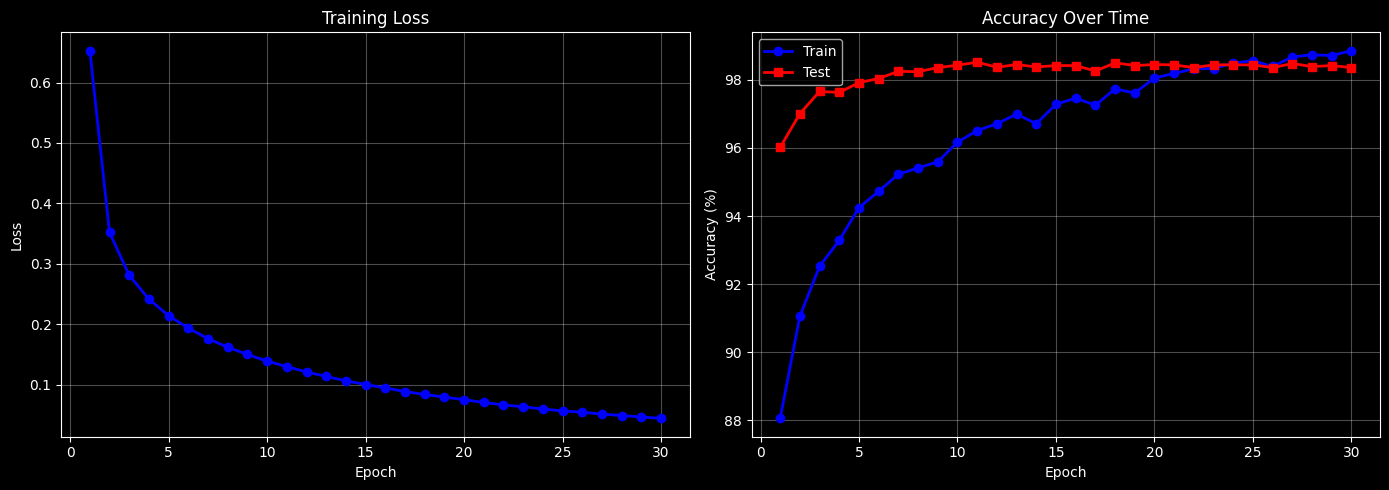

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, num_epochs+1), train_losses, marker="o", linewidth=2, color="blue")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, num_epochs+1), train_accuracies, marker="o", linewidth=2,
         color="blue", label="Train")
ax2.plot(range(1, num_epochs+1), test_accuracies, marker="s", linewidth=2,
         color="red", label="Test")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

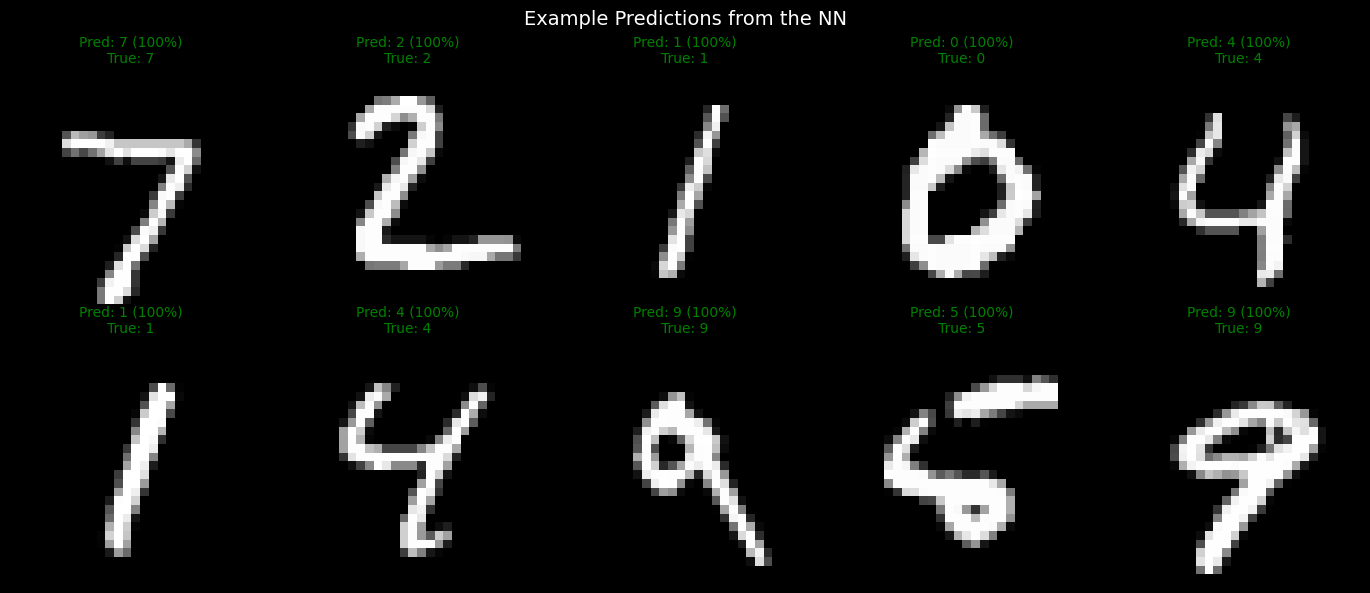

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i, ax in enumerate(axes.flat):
    image = test_images[i]
    true_label = test_labels[i]

    probs = net.forward_pass(image.reshape(1, -1))
    predicted = np.argmax(probs)
    confidence = probs[0, predicted]

    ax.imshow(image.reshape(28, 28), cmap="gray")
    color = "green" if predicted == true_label else "red"
    ax.set_title(f"Pred: {predicted} ({confidence:.0%})\nTrue: {true_label}",
                 color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("Example Predictions from the NN", fontsize=14)
plt.tight_layout()
plt.show()

The Last step is to save the trained model in a file for later use.

In [14]:
def get_highest_model_filename(directory: str = MODELS_DIR) -> str | None:
    """
    Find the filename of the saved model with the highest version number in the given directory.

    Args:
        directory (str): Directory to search for models.

    Returns:
        str | None: Filename of the model with highest version or None if no model found.
    """
    pattern = re.compile(r"mnist_model_v(\d+)\.npz")
    highest_version = 0
    found = False

    os.makedirs(directory, exist_ok=True)
    
    for filename in os.listdir(directory):
        match = pattern.fullmatch(filename)
        if match:
            version = int(match.group(1))
            highest_version = max(highest_version, version)
            found = True
            
    if not found:
        return None

    return f"mnist_model_v{highest_version}.npz"
    
    
def get_next_model_filename(directory: str = MODELS_DIR) -> str:
    """
    Generate a filename for the next model with incremented version number.

    Args:
        directory (str): Directory where models are saved.

    Returns:
        str: New model filename.
    """
    highest_model_filename = get_highest_model_filename(directory)
    
    if highest_model_filename is None:
        return f"mnist_model_v0.npz"
    
    pattern = re.compile(r"mnist_model_v(\d+)\.npz")
    match = pattern.fullmatch(highest_model_filename)
    version = int(match.group(1))
    
    return f"mnist_model_v{version + 1}.npz"

model_filename = get_next_model_filename()

net.save_with_metadata(
    model_filename,
    num_epochs,
    learning_rate,
    batch_size,
    train_accuracies[-1],
    test_accuracies[-1]
)

highest_model_filename = get_highest_model_filename()

if highest_model_filename is not None:
    test_net = NeuralNetwork()
    test_net.load(get_highest_model_filename())
    test_preds = test_net.predict(test_images)
    test_acc = np.mean(test_preds == test_labels) * 100
    print(f"Loaded model test accuracy: {test_acc:.2f}% — Ready for NumberAnalyser.py!")
else:
    print("An Error Occurred! No model file found")


Model saved to ../models\mnist_model_v10
Model loaded from ../models\mnist_model_v10.npz
Loaded model test accuracy: 98.36% — Ready for NumberAnalyser.py!
